# Download data from NASA EarthAccess
This code snippet provides an example of accessing and downloading data from NASA EarthData the `earthaccess` Python library (see the [docs](https://earthaccess.readthedocs.io/en/latest/user/quick-start/)).

You will first need to register for (free) Earth Data access: https://urs.earthdata.nasa.gov/home.

## Setup

In [1]:
# Install earthaccess
!pip install earthaccess
# !conda install -c conda-forge earthaccess

In [12]:
import earthaccess
import xarray as xr
from pathlib import Path

In [5]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

Enter your Earthdata Login username:  alexsaunders
Enter your Earthdata password:  ········


## Data search

Here is where you'll **update using your own search parameters:**
* The sensor / product name: known as the **collection**
* The region: here defined using a **bounding box**
* The time period: here defined using a **start and end date**
* Count: number of items to limit your search to - especially if you are searching a long date range, the search can return many items which can overwhelm your machine

There are **many additional arguments** you can use to further refine your search, for example for optical data try `cloud_cover=(0,50)` to filter by cloud cover. Read more about the earthaccess search here: https://earthaccess.readthedocs.io/en/latest/user/search/

In [6]:
# Search for data
# This example retries data from ICESAT
results = earthaccess.search_data(
    short_name='ATL06',
    bounding_box=(-10, 20, 10, 50),
    temporal=("1999-02", "2019-03"),
    count=10 # Limits to max number of query results
)

# Briefly show the search results
print(f'Search returned {len(results)} results')
print('\nShowing the first result:\n', results[0])

Search returned 10 results

Showing the first result:
 Collection: {'EntryTitle': 'ATLAS/ICESat-2 L3A Land Ice Height V007'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 0.37223, 'Latitude': 54.41191}, {'Longitude': 0.18146, 'Latitude': 54.42292}, {'Longitude': 0.07996, 'Latitude': 53.80811}, {'Longitude': -0.37192, 'Latitude': 50.93058}, {'Longitude': -0.56602, 'Latitude': 49.62908}, {'Longitude': -0.6439, 'Latitude': 49.0956}, {'Longitude': -1.10602, 'Latitude': 45.80076}, {'Longitude': -1.53111, 'Latitude': 42.57971}, {'Longitude': -1.96989, 'Latitude': 39.07614}, {'Longitude': -2.4056, 'Latitude': 35.43036}, {'Longitude': -3.27622, 'Latitude': 27.71327}, {'Longitude': -3.3577, 'Latitude': 26.96459}, {'Longitude': -3.23279, 'Latitude': 26.95369}, {'Longitude': -3.15052, 'Latitude': 27.70231}, {'Longitude': -2.26913, 'Latitude': 35.41904}, {'Longitude': -1.82665, 'Latitude': 39.06512}, {'Longitude': -1.38012, 'Latitu

In [8]:
# Look at the first result from our search
result = results[0]

# Notice the type - earthaccess.results.DataGranule
# Read more about data granules: https://www.earthdata.nasa.gov/news/feature-articles/data-tool-focus-earthdata-search
print(type(result))

# It comes with interactive clickable elements, including a link to the data file
result

<class 'earthaccess.results.DataGranule'>


Collection: {'EntryTitle': 'ATLAS/ICESat-2 L3A Land Ice Height V007'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 0.37223, 'Latitude': 54.41191}, {'Longitude': 0.18146, 'Latitude': 54.42292}, {'Longitude': 0.07996, 'Latitude': 53.80811}, {'Longitude': -0.37192, 'Latitude': 50.93058}, {'Longitude': -0.56602, 'Latitude': 49.62908}, {'Longitude': -0.6439, 'Latitude': 49.0956}, {'Longitude': -1.10602, 'Latitude': 45.80076}, {'Longitude': -1.53111, 'Latitude': 42.57971}, {'Longitude': -1.96989, 'Latitude': 39.07614}, {'Longitude': -2.4056, 'Latitude': 35.43036}, {'Longitude': -3.27622, 'Latitude': 27.71327}, {'Longitude': -3.3577, 'Latitude': 26.96459}, {'Longitude': -3.23279, 'Latitude': 26.95369}, {'Longitude': -3.15052, 'Latitude': 27.70231}, {'Longitude': -2.26913, 'Latitude': 35.41904}, {'Longitude': -1.82665, 'Latitude': 39.06512}, {'Longitude': -1.38012, 'Latitude': 42.56871}, {'Longitude': -0.94657, 'Latitude': 45.78977}, {'Longitude': -0.47418, 'Latitude': 49.08454}, {'Longitude': -0.39442, 'Latitude': 49.61827}, {'Longitude': -0.1956, 'Latitude': 50.91965}, {'Longitude': 0.26807, 'Latitude': 53.79691}, {'Longitude': 0.37223, 'Latitude': 54.41191}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2018-10-14T03:45:14.224Z', 'EndingDateTime': '2018-10-14T03:52:24.099Z'}}
Size(MB): 96.0
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2018/10/14/ATL06_20181014034354_02370106_007_01.h5']

## Open or download data

You have the option to either stream the data into Python or download the data. 

In both cases, you will first need to specify the files from your search that you want to download. You can either download all of them, or choose specific files from the list we just got.

### Data streaming

In [9]:
# Stream / open files
result_to_stream = results[0] # you could take more than one here

# earthaccess.open expects a list, so even if you just want one data file it must be inside a list []
streamed = earthaccess.open([result_to_stream])
streamed

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object S3FileSystem, nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2018/10/14/ATL06_20181014034354_02370106_007_01.h5>]

In [10]:
# Open the streamed file with xarray open_dataset
# Note, since this is an h5 hierarchical structure file, we need to specify the group to get the DataSet we want
data = xr.open_dataset(streamed[0], group="gt1l/land_ice_segments")
data

<xarray.Dataset> Size: 4MB
Dimensions:                (delta_time: 90876)
Coordinates:
  * delta_time             (delta_time) datetime64[ns] 727kB 2018-10-14T03:45...
    latitude               (delta_time) float64 727kB ...
    longitude              (delta_time) float64 727kB ...
Data variables:
    atl06_quality_summary  (delta_time) int8 91kB ...
    fpb_warning_flag       (delta_time) int8 91kB ...
    h_li                   (delta_time) float32 364kB ...
    h_li_sigma             (delta_time) float32 364kB ...
    segment_id             (delta_time) float64 727kB ...
    sigma_geo_h            (delta_time) float32 364kB ...
Attributes:
    data_rate:    Data within this group are sparse.  Data values are provide...
    description:  The land_ice_height group contains the primary set of deriv...

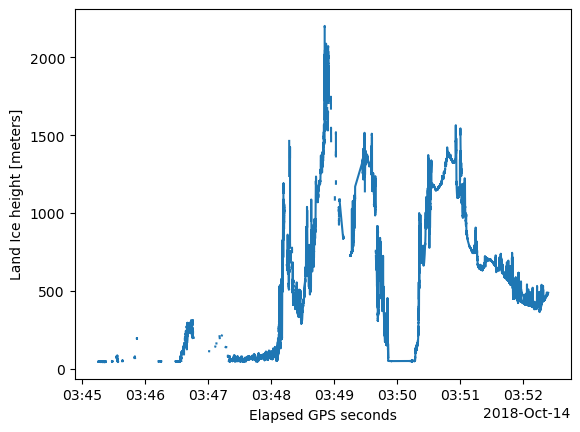

In [11]:
# Plot the standard land-ice segment height variable 
data['h_li'].plot()

### Data download

In [15]:
# Download files
# As with the data stream, choose which files you want to download
# This could be one or many files
results_to_download = results[:2] # first two

# Download using earthaccess.download()
downloadPath = Path('data/downloads/ATL06') # MODIFY
files = earthaccess.download(results_to_download, downloadPath)

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [16]:
# Check the files that were downloaded
sorted(downloadPath.iterdir())

[PosixPath('data/downloads/ATL06/ATL06_20181014034354_02370106_007_01.h5'),
 PosixPath('data/downloads/ATL06/ATL06_20181014035224_02370107_007_01.h5')]

## Dataset search

If you don't already know which dataset (collection) you want to work with, you can also use earthaccess to search for datasets using a keyword (before you search for individual data files). There are lots of arguments to help refine your search: https://earthaccess.readthedocs.io/en/latest/user/search/

In [25]:
dataset_results = earthaccess.search_datasets(
    keyword="MODIS", #icesat-2
    downloadable=True,
    cloud_hosted=True)

# Briefly show the search results
print(f'Dataset search returned {len(dataset_results)} results')
print('\nShowing the first result:\n', dataset_results[0].summary())

Dataset search returned 1540 results

Showing the first result:
 {'short-name': 'Aqua_AIRS_MODIS1km_IND', 'concept-id': 'C2515837343-GES_DISC', 'version': '1', 'file-type': '', 'get-data': ['https://measures.gesdisc.eosdis.nasa.gov/data/AIRS_CloudSat/Aqua_AIRS_MODIS1km_IND.1/', 'https://search.earthdata.nasa.gov/search/granules?p=C2515837343-GES_DISC'], 'cloud-info': {'Region': 'us-west-2', 'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials', 'S3CredentialsAPIDocumentationURL': 'https://data.gesdisc.earthdata.nasa.gov/s3credentialsREADME', 'S3BucketAndObjectPrefixNames': ['s3://gesdisc-cumulus-prod-protected/AIRS_CloudSat/Aqua_AIRS_MODIS1km_IND.1/']}}
